In [89]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

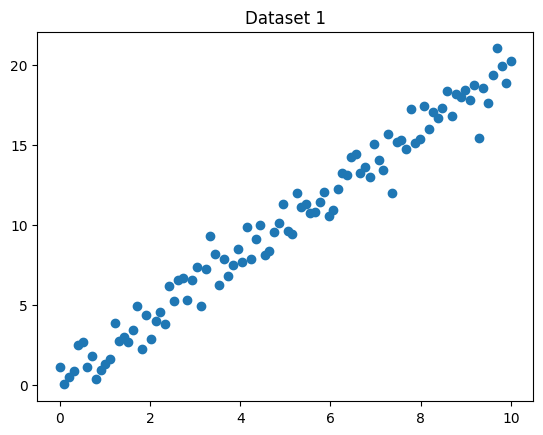

In [90]:
x1 = np.linspace(0, 10, 100)
y1 = 2 * x1 + np.random.normal(0, 1, 100)

plt.scatter(x1, y1)
plt.title("Dataset 1")
plt.show()

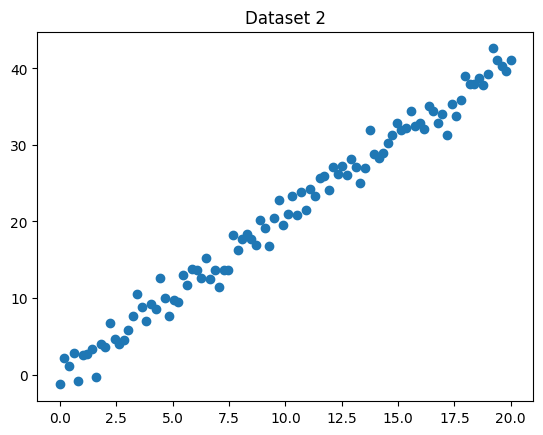

In [91]:
x2 = np.linspace(0, 20, 100)
y2 = 2.1 * x2 + np.random.normal(0, 1.5, 100)

plt.scatter(x2, y2)
plt.title("Dataset 2")
plt.show()

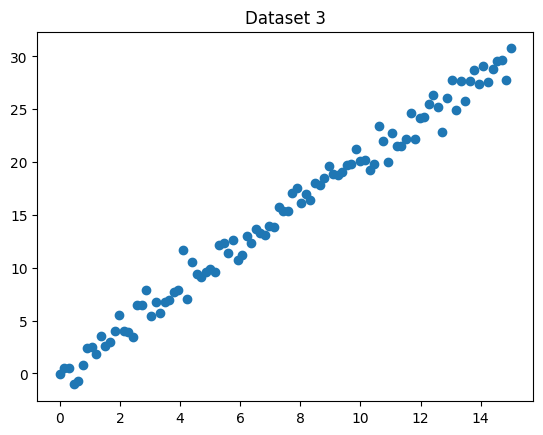

In [92]:
x3 = np.linspace(0, 15, 100)
y3 = 2 * x3 + np.random.normal(0, 1, 100)

plt.scatter(x3, y3)
plt.title("Dataset 3")
plt.show()

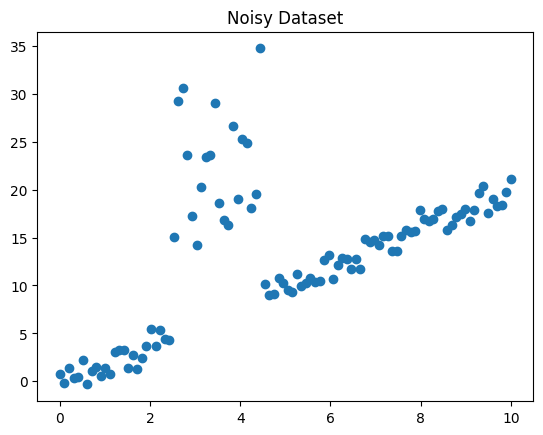

In [93]:
x_noise = np.linspace(0, 10, 100)
y_noise = 2 * x_noise + np.random.normal(0, 1, 100)

y_noise[25:45] += np.random.normal(15, 5, 20)

plt.scatter(x_noise, y_noise)
plt.title("Noisy Dataset")
plt.show()

In [94]:
X_train = x1.reshape(-1, 1)
y_train = y1

model = LinearRegression()
model.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


In [95]:
def evaluate_model(x, y, dataset_name):
    X = x.reshape(-1, 1)

    predictions = model.predict(X)
    r2 = r2_score(y, predictions)
    mse = mean_squared_error(y, predictions)

    print(f"\nДатасет: {dataset_name}")
    print(f"R2 Score: {r2:.3f}")
    print(f"MSE: {mse:.3f}")

    plt.scatter(x, y, label='Real data')
    plt.plot(x, predictions, color='red', label='Prediction')
    plt.title(dataset_name)
    plt.legend()
    plt.show()

    return r2


Датасет: Dataset 1
R2 Score: 0.972
MSE: 0.938


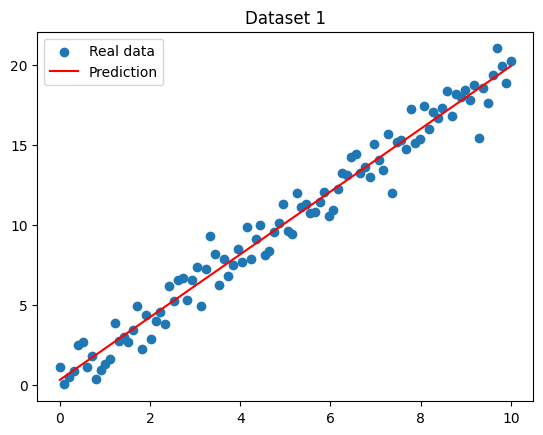


Датасет: Dataset 2
R2 Score: 0.977
MSE: 3.397


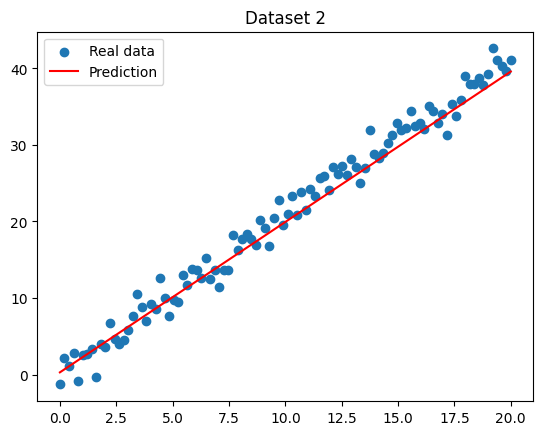


Датасет: Dataset 3
R2 Score: 0.985
MSE: 1.139


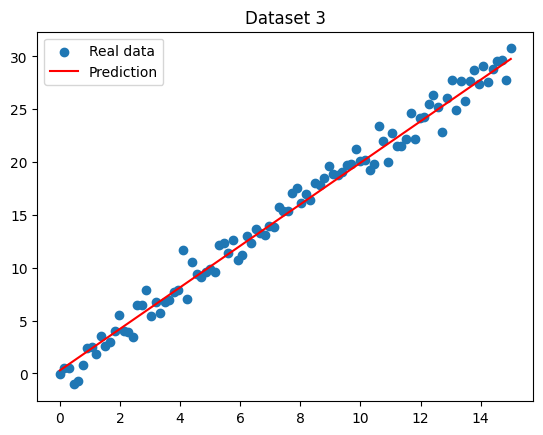


Датасет: Noisy Dataset
R2 Score: 0.130
MSE: 52.969


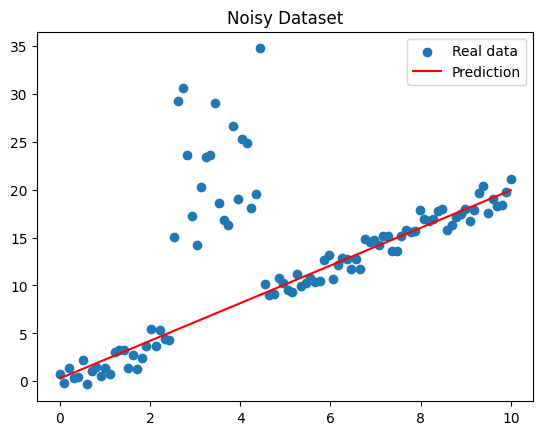

In [96]:
r2_1 = evaluate_model(x1, y1, "Dataset 1")
r2_2 = evaluate_model(x2, y2, "Dataset 2")
r2_3 = evaluate_model(x3, y3, "Dataset 3")
r2_noise = evaluate_model(x_noise, y_noise, "Noisy Dataset")

In [97]:
%%writefile lab5/tests/test_model.py

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x_train = np.linspace(0, 10, 100)
y_train = 2 * x_train + np.random.normal(0, 1, 100)
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)


def test_dataset_1():
    x = np.linspace(0, 10, 100)
    y = 2 * x + np.random.normal(0, 1, 100)
    predictions = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, predictions)
    assert r2 > 0.8


def test_dataset_2():
    x = np.linspace(0, 20, 100)
    y = 2.1 * x + np.random.normal(0, 1.5, 100)
    predictions = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, predictions)
    assert r2 > 0.8


def test_dataset_3():
    x = np.linspace(0, 15, 100)
    y = 2 * x + np.random.normal(0, 1, 100)
    predictions = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, predictions)
    assert r2 > 0.8


def test_noisy_dataset():
    x = np.linspace(0, 10, 100)
    y = 2 * x + np.random.normal(0, 1, 100)
    y[25:45] += np.random.normal(15, 5, 20)
    predictions = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, predictions)
    assert r2 > 0.8

Overwriting lab5/tests/test_model.py


In [98]:
!pytest lab5/tests -v

============================= test session starts =============================
platform win32 -- Python 3.11.0, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\Владимир\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Windows\system32
plugins: anyio-4.12.0
collecting ... collected 4 items

lab5/tests/test_model.py::test_dataset_1 PASSED                          [ 25%]
lab5/tests/test_model.py::test_dataset_2 PASSED                          [ 50%]
lab5/tests/test_model.py::test_dataset_3 PASSED                          [ 75%]
lab5/tests/test_model.py::test_noisy_dataset FAILED                      [100%]

================================== FAILURES ===================================
_____________________________ test_noisy_dataset ______________________________

    def test_noisy_dataset():
        x = np.linspace(0, 10, 100)
        y = 2 * x + np.random.normal(0, 1, 100)
        y[25:45] += np.random.normal(15, 5, 20)
        predictions = model.predict